# Structural neurotransmitter fingerprinting

In this tutorial, you will explore the structural neurotransmitter fingerprinting (SNTF) functionalities of Lacuna using the CLI.

**What you'll learn**:

- Fetch the neurotransmitter PET atlas and a structural connectome
- Prepare the atlas and precompute endpoint weights
- Compute NT-weighted structural disconnectivity scores
- Filter by neurotransmitter system

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/m-petersen/lacuna/blob/main/docs/tutorials/07-structural-neurotransmitter-fingerprinting.ipynb)

## Colab

Note: Colab provides limited computational resources. While these tutorials are designed to operate within those constraints, some Lacuna functionality cannot be fully demonstrated in this environment and requires access to higher-performance computing infrastructure.

Ignore this if you run this notebook locally.

In [ ]:
# --- Conda setup for Google Colab ---
# Lacuna's structural neurotransmitter fingerprinting relies on MRtrix3.
# However, Colab does not provide MRtrix3 out of the box.
# The condacolab package provides a workaround.
# This cell installs condacolab, which will restart the kernel.
!pip install -q condacolab
import condacolab
condacolab.install()

In [ ]:
# Run this after the kernel restart. 
import sys

if 'google.colab' in sys.modules:

    import condacolab
    import subprocess
    condacolab.check()
    subprocess.run(["conda", "install", "-y", "-c", "mrtrix3", "mrtrix3"], check=True)
else:
    print("Not running in Colab — skipping condacolab setup.")

## Setup

In [ ]:
# Install Lacuna from GitHub
!pip install git+https://github.com/m-petersen/lacuna

# Install MRtrix3 via conda
!conda install -y -c mrtrix3 mrtrix3

Get the tutorial data.

In [2]:
# Get tutorial data
!lacuna tutorial /tmp/tutorial_bids --force


Setting up tutorial data at: /tmp/tutorial_bids
✓ Tutorial data copied to: /tmp/tutorial_bids

The tutorial dataset includes:
  - 3 synthetic subjects (sub-01, sub-02, sub-03)
  - Binary lesion masks in MNI152NLin6Asym space
  - BIDS-style structure


Check whether MRtrix3 is properly installed as it is required for the analysis.

In [1]:
!mrinfo --version

== mrinfo 3.0.8 ==
64 bit release version, built Oct 21 2025, using Eigen 3.4.0
Author(s): J-Donald Tournier (jdtournier@gmail.com) and Robert E. Smith (robert.smith@florey.edu.au)
Copyright (c) 2008-2025 the MRtrix3 contributors.

This Source Code Form is subject to the terms of the Mozilla Public
License, v. 2.0. If a copy of the MPL was not distributed with this
file, You can obtain one at http://mozilla.org/MPL/2.0/.

Covered Software is provided under this License on an "as is"
basis, without warranty of any kind, either expressed, implied, or
statutory, including, without limitation, warranties that the
Covered Software is free of defects, merchantable, fit for a
particular purpose or non-infringing.
See the Mozilla Public License v. 2.0 for more details.

For more details, see http://www.mrtrix.org/.



## Fetch data

SNTF requires two data sources:

1. **Neurotransmitter PET atlas** — curated representative PET receptor / transporter density maps from [NiSpace-data](https://github.com/LeonDLotter/NiSpace-data)
2. **Structural connectome** — A normative tractogram of white matter fiber bundles.

In [5]:
# Fetch NT atlas
!lacuna fetch ntatlas \
    --output-dir /tmp/ntatlas_data \
    --force

Fetching neurotransmitter PET maps...
  Source: https://github.com/LeonDLotter/NiSpace-data
  Commit: a772c410f76dbbd022a3f5239e40176ff6f930c7


✓ Neurotransmitter atlas fetch complete!
  Files: 22
  Duration: 8.7s
  Output: /tmp/ntatlas_data


Although we use HCP1065 here for demonstration purposes. We recommend using dTOR985 for structural neurotransmitter fingerprinting as it has higher coverage.

In [6]:
# Fetch structural connectome
!lacuna fetch hcp1065 \
    --output-dir /tmp/hcp1065_data

Fetching HCP1065 structural tractogram...
  Output: /tmp/hcp1065_data
  Keep original: True

hcp1065_avg_tracts_trk.zip: 100%|████████████| 588M/588M [00:15<00:00, 37.2MB/s]
Found 77 tract files (10 excluded)
Loading and merging streamlines...
Merging tracts: 100%|███████████████████████████| 77/77 [00:16<00:00,  4.53it/s]
Processed 77 files, 479804 total streamlines
Saving merged tractogram to /tmp/hcp1065_data/hcp1065.tck...
Merge complete: /tmp/hcp1065_data/hcp1065.tck

✓ HCP1065 fetch complete!
  Files: 2
  Duration: 41.8s
  Output: /tmp/hcp1065_data


## Precompute endpoint weights

`lacuna prepare sntf` builds an (atlas, tractogram) cache of per-streamline NT values at both endpoints for every target. The slow `tckresample` and per-target voxel lookups happen **once** here; afterwards every `lacuna run sntf` only needs a single per-subject `tckedit` and a numpy lookup. The cache is required — sntf does not have an on-the-fly fallback.

In [60]:
# Step 2: Precompute endpoint weights for the tractogram
!lacuna prepare sntf \
    --ntatlas-dir /tmp/ntatlas_data \
    --connectome-path ~/dtor985_data/dTOR_full_tractogram.tck \
    --cache-dir /tmp/sntf_cache

2026-04-29 17:59:20 - lacuna.cli.prepare - INFO - Loaded NT atlas with 22 targets
2026-04-29 17:59:20 - lacuna.cli.prepare - INFO - Computing endpoint NT weights for tractogram...
   Executing: tckresample /home/marvin/dtor985_data/dTOR_full_tractogram.tck /tmp/sntf_cache/endpoints.tck -endpoints -force
tckresample: [WARNING] existing output files will be overwritten
tckresample: [done] resampling streamlines (count: 11820000, skipped: 0)
2026-04-29 18:03:16 - lacuna.cli.prepare - INFO - Cached endpoint weights for 11820000 streamlines × 22 targets
Endpoint weights saved to /tmp/sntf_cache


## Analysis

Structural neurotransmitter fingerprinting combines structural disconnection with neurotransmitter information. It:

1. Filters the normative tractogram by the lesion mask to identify disconnected streamlines
2. Looks up NT atlas values at the endpoints of those disconnected streamlines
3. Scores each neurotransmitter target based on the endpoint values

A high score for a given target indicates that the lesion disconnects pathways whose endpoints are rich in that neurotransmitter.

This procedure follows the implementation by [Koch, Frey et al](https://academic.oup.com/brain/article-lookup/doi/10.1093/brain/awaf185).

Run the analysis.

In [ ]:
!lacuna run sntf \
    /tmp/tutorial_bids/ \
    /tmp/outputs_sntf/ \
    --connectome-path ~/dtor985_data/dTOR_full_tractogram.tck \
    --participant-label 01 \
    --mask-space MNI152NLin6Asym \
    --ntatlas-dir /tmp/ntatlas_data \
    --precomputed-weights-dir /tmp/sntf_cache \
    --keep-intermediate \
    --verbose


2026-04-29 18:04:53 - lacuna.cli.main - INFO - Lacuna CLI starting
2026-04-29 18:04:53 - lacuna.cli.main - INFO - Input: /tmp/tutorial_bids
2026-04-29 18:04:53 - lacuna.cli.main - INFO - Output directory: /tmp/outputs_sntf
2026-04-29 18:04:53 - lacuna.cli.main - INFO - Analysis: sntf
2026-04-29 18:04:53 - lacuna.cli.main - INFO - Registering structural connectome: dTOR_full_tractogram.tck
2026-04-29 18:04:53 - lacuna.cli.main - INFO - Running analysis: StructuralNeurotransmitterFingerprinting
2026-04-29 18:04:53 - lacuna.cli.main - INFO - 
2026-04-29 18:04:53 - lacuna.cli.main - INFO - ============================================================
2026-04-29 18:04:53 - lacuna.cli.main - INFO - DISCOVERY SUMMARY
2026-04-29 18:04:53 - lacuna.cli.main - INFO - ============================================================
2026-04-29 18:04:53 - lacuna.cli.main - INFO -   Total mask images: 1
2026-04-29 18:04:53 - lacuna.cli.main - INFO -   Unique subjects:   1
2026-04-29 18:04:53 - lacuna.cli.

List the outputs.

In [52]:
!ls /tmp/outputs_sntf/sub-01/ses-01/anat/

sub-01_ses-01_label-acuteinfarct_method-sntf_atlas-neurotransmitter_desc-static_profilestats.json
sub-01_ses-01_label-acuteinfarct_method-sntf_atlas-neurotransmitter_desc-static_profilestats.tsv
sub-01_ses-01_label-acuteinfarct_method-sntf_space-MNI152NLin6Asym_desc-endpointdensity.json
sub-01_ses-01_label-acuteinfarct_method-sntf_space-MNI152NLin6Asym_desc-endpointdensity.nii.gz


## Visualize the fingerprint

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

tsv = next(Path("/tmp/outputs_sntf/sub-01/ses-01/anat").glob("*sntf*profilestats.tsv"))
df = pd.read_csv(tsv, sep="\t")

targets = df["target"].tolist()
values = df["value"].to_numpy()
angles = np.linspace(0, 2 * np.pi, len(targets), endpoint=False)

fig, ax = plt.subplots(figsize=(6, 6), subplot_kw=dict(projection="polar"))
ax.plot(np.append(angles, angles[0]), np.append(values, values[0]),
        color="steelblue", linewidth=1.5)
ax.fill(np.append(angles, angles[0]), np.append(values, values[0]),
        color="steelblue", alpha=0.25)
ax.set_xticks(angles)
ax.set_xticklabels(targets, fontsize=9)
ax.set_title("sub-01", pad=20)
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
plt.tight_layout()
plt.show()


## Disconnected endpoints alongside the top NT target

We re-ran sntf with `--keep-intermediate`, which writes a per-subject endpoint-density NIfTI (counts of lesion-disconnected streamline endpoints per voxel) into the BIDS output directory. Overlay it on the highest-scoring NT map to see *where* the disrupted white-matter bundles terminate.

tckedit: [WARNING] existing output files will be overwritten
tckedit: uncompressing image "/tmp/tutorial_bids/sub-01/ses-01/anat/sub-01_ses-01_space-MNI152NLin6Asym_label-acuteinfarct_mask.nii.gz"... [==================================================]
tckedit: [.   ]        1 read,        0 written
tckedit: [ .  ]     1921 read,        0 written
tckedit: [  . ]     4225 read,        0 written
tckedit: [  . ]    14209 read,        0 written
tckedit: [  . ]    31489 read,        0 written
tckedit: [  . ]    79361 read,      106 written
tckedit: [  . ]   141825 read,     2559 written
tckedit: [  . ]   374145 read,     3322 written
tckedit: [done]   479804 read,     7937 written
tckresample: [WARNING] existing output files will be overwritten
tckresample: [done] resampling streamlines (count: 7937, skipped: 0)
/tmp/ipykernel_1447527/3801820868.py:46: UserWarning: kwargs['alpha']=0.7 detected in parameters.
Overriding with transparency=None.
To suppress this warning pass your 'alpha' value

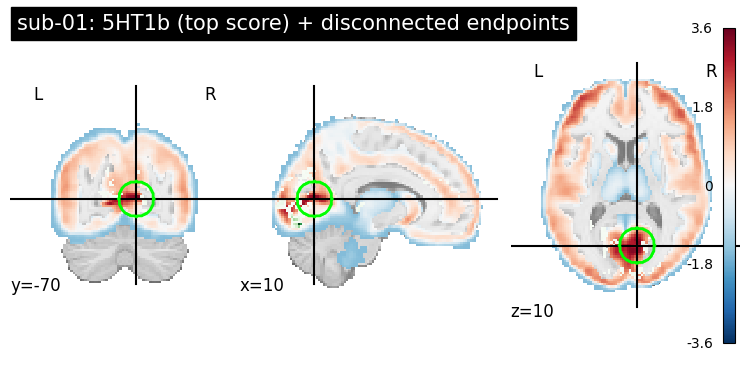

In [ ]:
import nibabel as nib
import numpy as np
import pandas as pd
from pathlib import Path
from nilearn import plotting

anat_dir = Path("/tmp/outputs_sntf/sub-01/ses-01/anat")
df = pd.read_csv(next(anat_dir.glob("*sntf*profilestats.tsv")), sep="\t")
top_target = df["target"].iloc[df["value"].argmax()]

nt_map = nib.load(f"/tmp/ntatlas_data/maps/{top_target}.nii.gz")
density_img = nib.load(next(anat_dir.glob("*method-sntf*desc-endpointdensity*.nii.gz")))
lesion_path = next(Path("/tmp/tutorial_bids/sub-01/ses-01/anat").glob("*mask*.nii.gz"))

centroid = nib.affines.apply_affine(
    nib.load(lesion_path).affine,
    np.argwhere(nib.load(lesion_path).get_fdata() > 0).mean(axis=0),
)
display = plotting.plot_stat_map(
    nt_map, threshold=1.0, display_mode="ortho", cut_coords=tuple(centroid),
    title=f"sub-01: {top_target} (top score) + disconnected endpoints",
    colorbar=True,
)
display.add_overlay(density_img, cmap="autumn", alpha=0.7)
display.add_contours(str(lesion_path), levels=[0.5], colors="lime", linewidths=2)
plotting.show()


## Cache validation

The cache directory contains a `lacuna_asset.json` recording the
fingerprints of the tractogram and NT atlas it was built from. If
`lacuna run sntf` is later pointed at a different `--connectome-path`
or `--ntatlas-dir`, the run aborts with an `AssetMismatchError` rather
than silently producing wrong scores. See [Asset
envelopes](../explanation/asset-envelope.md) for details.
